In [1]:
!pip install seaborn matplotlib

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.10.7-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.60.1-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (112 kB)
  Using cached kiwisolver-1.4.9-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (6.3 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached matplotlib-3.10.7-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.7 MB)
Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (325 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.60.1-cp310-cp310-manylinux2014_x86_64.many

In [8]:
import os
import json
import torch
import numpy as np
import pandas as pd
import cv2
import os
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.ops import box_convert
import glob
import re
from PIL import Image, ImageDraw, ImageFont
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from transformers import AutoModelForVision2Seq, AutoProcessor

In [4]:
%pip uninstall -y transformers -q
!python -m pip install --upgrade --force-reinstall git+https://github.com/huggingface/transformers -q

Note: you may need to restart the kernel to use updated packages.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer 0.15.4 requires click<8.2,>=8.0.0, but you have click 8.3.1 which is incompatible.

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [3]:
!pip install -q accelerate


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [6]:
!pip install -q opencv-python matplotlib numpy pillow accelerate bitsandbytes

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [10]:
class QwenAttentionVisualizer:
    def __init__(self, model_path="Qwen/Qwen3-VL-4B-Instruct", device="cuda"):
        print(f"--- Loading {model_path} ---")
        self.device = device
        self.model = AutoModelForVision2Seq.from_pretrained(
            model_path, torch_dtype=torch.float16, _attn_implementation="eager", 
            trust_remote_code=True, device_map=device
        )
        self.processor = AutoProcessor.from_pretrained(model_path, trust_remote_code=True)

    def get_attention_data(self, image_path, caption):
        messages = [
            {"role": "user", "content": [{"type": "image", "image": image_path}, {"type": "text", "text": "Generate a detailed caption."}]},
            {"role": "assistant", "content": [{"type": "text", "text": caption}]}
        ]
        text_prompt = self.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
        inputs = self.processor(
            text=[text_prompt], images=[Image.open(image_path)], padding=True, return_tensors="pt"
        ).to(self.device)
        
        with torch.no_grad():
            outputs = self.model(**inputs, output_attentions=True)
        return outputs.attentions, inputs

    def generate_overlay(self, attentions, inputs, image_path, layer_idx):
        """Generate attention overlay from LAST token to all image tokens"""
        input_ids = inputs.input_ids[0].cpu().numpy()
        
        # Locate Image Tokens
        try:
            vision_start_id = self.processor.tokenizer.convert_tokens_to_ids("<|vision_start|>")
            start_indices = np.where(input_ids == vision_start_id)[0]
            if len(start_indices) == 0: return None
            img_start_idx = start_indices[0] + 1
            img_end_idx = img_start_idx + 256 
        except: return None

        attention_mask = inputs.attention_mask[0].cpu().numpy()
        last_token_idx = np.where(attention_mask == 1)[0][-1]
        
        # Extract Attention from LAST token -> Image Tokens
        layer_attn = attentions[layer_idx][0].mean(dim=0)  # Average over heads
        
        # Change the first index from 'first_text_token_idx' to 'last_token_idx'
        raw_attn = layer_attn[last_token_idx, img_start_idx:img_end_idx]
        # --- CHANGE END ---

        heatmap_16x16 = raw_attn.view(16, 16).float().cpu().numpy()
        
        # Process Image (Rest of the code remains exactly the same)
        img_pil = Image.open(image_path).convert("RGB")
        w, h = img_pil.size
        img_np = np.array(img_pil)
        
        heatmap_resized = cv2.resize(heatmap_16x16, (w, h), interpolation=cv2.INTER_CUBIC)
        heatmap_norm = (heatmap_resized - heatmap_resized.min()) / (heatmap_resized.max() - heatmap_resized.min() + 1e-8)
        heatmap_uint8 = (heatmap_norm * 255).astype(np.uint8)
        heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
        
        overlay = cv2.addWeighted(img_np, 0.5, heatmap_color, 0.5, 0)
        return img_np, overlay
        
def generate_web_assets(visualizer, json_dir, image_dir, output_dir, layers=[5, 15, 25, 30], limit=10):
    os.makedirs(output_dir, exist_ok=True)
    
    # Create subdirectories for each layer
    for layer in layers:
        layer_dir = os.path.join(output_dir, f"layer_{layer}")
        os.makedirs(layer_dir, exist_ok=True)
    
    json_files = sorted([f for f in os.listdir(json_dir) if f.endswith('.json')])[:limit]
    
    web_metadata = {} 
    print(f"--- Processing {len(json_files)} Images for Web ---")
    
    for json_file in json_files:
        print(f"\nProcessing: {json_file}")
        
        try:
            with open(os.path.join(json_dir, json_file), 'r') as f: data = json.load(f)
        except: continue
            
        img_filename = data['image']
        caption = data['caption']
        image_path = os.path.join(image_dir, img_filename)
        image_id = img_filename.replace('.', '_')
        
        if not os.path.exists(image_path): continue
        
        # Initialize Metadata
        web_metadata[image_id] = {
            "filename": img_filename,
            "caption": caption,
            "layers": layers
        }
        
        # Run Model ONCE
        attentions, inputs = visualizer.get_attention_data(image_path, caption)
        
        # Generate for each layer
        for layer in layers:
            result = visualizer.generate_overlay(attentions, inputs, image_path, layer_idx=layer)
            
            if result:
                original_img, overlay_img = result
                combined = np.hstack((original_img, overlay_img))
                
                # Save in layer-specific subdirectory
                layer_dir = os.path.join(output_dir, f"layer_{layer}")
                save_name = f"{image_id}_LastImageToken.jpg"  # Simpler name since layer is in folder
                save_path = os.path.join(layer_dir, save_name)
                
                Image.fromarray(combined).save(save_path)
        
        print(f"Processed {len(layers)} layers.")
        
        del attentions, inputs
        torch.cuda.empty_cache()

    # Save metadata
    js_path = os.path.join(output_dir, "data.js")
    with open(js_path, 'w') as f:
        json_str = json.dumps(web_metadata, indent=4)
        f.write(f"window.ATTENTION_DATA = {json_str};")
    
    print(f"\nWeb assets generation complete!")
    print(f"Directory structure:")
    for layer in layers:
        print(f"  - {output_dir}/layer_{layer}/")


'''
    def generate_overlay(self, attentions, inputs, image_path, target_word, layer_idx):
        input_ids = inputs.input_ids[0].cpu().numpy()
        
        # Locate Image Tokens
        try:
            vision_start_id = self.processor.tokenizer.convert_tokens_to_ids("<|vision_start|>")
            start_indices = np.where(input_ids == vision_start_id)[0]
            if len(start_indices) == 0: return None
            img_start_idx = start_indices[0] + 1
            img_end_idx = img_start_idx + 256 
        except: return None

        # Locate Target Word
        target_tokens = self.processor.tokenizer(" " + target_word, add_special_tokens=False).input_ids
        if not target_tokens: target_tokens = self.processor.tokenizer(target_word, add_special_tokens=False).input_ids
        
        seq_len = len(target_tokens)
        found_start = -1
        for i in range(len(input_ids) - seq_len, -1, -1):
            if np.array_equal(input_ids[i : i+seq_len], target_tokens):
                found_start = i
                break
        
        if found_start == -1: return None
        found_end = found_start + seq_len
        
        # Extract Attention
        layer_attn = attentions[layer_idx][0].mean(dim=0)
        raw_attn = layer_attn[found_start:found_end, img_start_idx:img_end_idx].mean(dim=0)
        heatmap_16x16 = raw_attn.view(16, 16).float().cpu().numpy()
        
        # Process Image
        img_pil = Image.open(image_path).convert("RGB")
        w, h = img_pil.size
        img_np = np.array(img_pil)
        
        heatmap_resized = cv2.resize(heatmap_16x16, (w, h), interpolation=cv2.INTER_CUBIC)
        heatmap_norm = (heatmap_resized - heatmap_resized.min()) / (heatmap_resized.max() - heatmap_resized.min() + 1e-8)
        heatmap_uint8 = (heatmap_norm * 255).astype(np.uint8)
        heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
        
        overlay = cv2.addWeighted(img_np, 0.5, heatmap_color, 0.5, 0)
        return img_np, overlay


# --- Web Asset Generator ---
def generate_web_assets(visualizer, json_dir, image_dir, output_dir, layers=[5, 15, 25, 30], limit=10):
    os.makedirs(output_dir, exist_ok=True)
    json_files = sorted([f for f in os.listdir(json_dir) if f.endswith('.json')])[:limit]
    
    # This dictionary will store all the data our HTML needs
    web_metadata = {} 
    
    print(f"--- Processing {len(json_files)} Images for Web ---")
    
    for json_file in json_files:
        print(f"\nProcessing: {json_file}")
        
        try:
            with open(os.path.join(json_dir, json_file), 'r') as f: data = json.load(f)
        except: continue
            
        img_filename = data['image']
        caption = data['caption']
        image_path = os.path.join(image_dir, img_filename)
        image_id = img_filename.replace('.', '_') # Safe ID for JS
        
        if not os.path.exists(image_path): continue
            
        targets = list(set([obj['obj_cls'] for obj in data['objects']]))
        
        # Initialize Metadata for this Image
        web_metadata[image_id] = {
            "filename": img_filename,
            "caption": caption,
            "objects": [],
            "layers": layers
        }
        
        # Run Model ONCE
        attentions, inputs = visualizer.get_attention_data(image_path, caption)
        
        for target in targets:
            # STRICT CHECK
            if target.lower() not in caption.lower():
                continue
                
            web_metadata[image_id]["objects"].append(target)
            
            # Generate Layers
            for layer in layers:
                result = visualizer.generate_overlay(attentions, inputs, image_path, target, layer_idx=layer)
                
                if result:
                    original_img, overlay_img = result
                    combined = np.hstack((original_img, overlay_img))
                    
                    # Naming Convention: {image_id}_{object}_L{layer}.jpg
                    save_name = f"{image_id}_{target}_L{layer}.jpg"
                    save_path = os.path.join(output_dir, save_name)
                    
                    Image.fromarray(combined).save(save_path)
        
        # Remove image if no valid objects found to keep UI clean
        if not web_metadata[image_id]["objects"]:
            del web_metadata[image_id]
        else:
            print(f"   ✅ Processed {len(web_metadata[image_id]['objects'])} objects.")

        del attentions, inputs
        torch.cuda.empty_cache()

    # Save Data for Web
    # We save as a .js file assigning a global variable so we can open index.html locally without CORS errors
    js_path = os.path.join(output_dir, "data.js")
    with open(js_path, 'w') as f:
        json_str = json.dumps(web_metadata, indent=4)
        f.write(f"window.ATTENTION_DATA = {json_str};")
    
    print(f"\n✅ Web assets generation complete! Open index.html to view.")
'''

# --- Run ---
visualizer = QwenAttentionVisualizer()
IMG_DIR = "VRSBench_val/Images_val"
JSON_DIR = "VRSBench_val/Annotations_val"
OUT_DIR = "Attention_Web_Viewer" 

--- Loading Qwen/Qwen3-VL-4B-Instruct ---


Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

In [12]:
layers = list(range(36))
generate_web_assets(visualizer, JSON_DIR, IMG_DIR, OUT_DIR, layers=layers, limit=5)

--- Processing 5 Images for Web ---

Processing: 05863_0000.json
Processed 36 layers.

Processing: 05864_0000.json
Processed 36 layers.

Processing: 05865_0000.json
Processed 36 layers.

Processing: 05866_0000.json
Processed 36 layers.

Processing: 05867_0000.json
Processed 36 layers.

Web assets generation complete!
Directory structure:
  - Attention_Web_Viewer/layer_0/
  - Attention_Web_Viewer/layer_1/
  - Attention_Web_Viewer/layer_2/
  - Attention_Web_Viewer/layer_3/
  - Attention_Web_Viewer/layer_4/
  - Attention_Web_Viewer/layer_5/
  - Attention_Web_Viewer/layer_6/
  - Attention_Web_Viewer/layer_7/
  - Attention_Web_Viewer/layer_8/
  - Attention_Web_Viewer/layer_9/
  - Attention_Web_Viewer/layer_10/
  - Attention_Web_Viewer/layer_11/
  - Attention_Web_Viewer/layer_12/
  - Attention_Web_Viewer/layer_13/
  - Attention_Web_Viewer/layer_14/
  - Attention_Web_Viewer/layer_15/
  - Attention_Web_Viewer/layer_16/
  - Attention_Web_Viewer/layer_17/
  - Attention_Web_Viewer/layer_18/
  - A

In [2]:
class AttentionEvaluator:
    def __init__(self, model_path="Qwen/Qwen3-VL-4B-Instruct", device="cuda"):
        print(f"--- Loading {model_path} ---")
        self.device = device
        self.model = AutoModelForVision2Seq.from_pretrained(
            model_path,
            torch_dtype=torch.float16,
            _attn_implementation="eager",
            trust_remote_code=True,
            device_map=device
        )
        self.processor = AutoProcessor.from_pretrained(model_path, trust_remote_code=True)
        
        # Robust Config Load
        if hasattr(self.model.config, "num_hidden_layers"):
            self.num_layers = self.model.config.num_hidden_layers
            self.num_heads = self.model.config.num_attention_heads
        elif hasattr(self.model.config, "text_config"):
            self.num_layers = self.model.config.text_config.num_hidden_layers
            self.num_heads = self.model.config.text_config.num_attention_heads
        else:
            self.num_layers = 36
            self.num_heads = 32

        print(f"Model loaded ({self.num_layers} layers, {self.num_heads} heads).")

    def get_attention_maps(self, image_path, caption):
        messages = [
            {"role": "user", "content": [{"type": "image", "image": image_path}, {"type": "text", "text": "Generate a detailed caption."}]},
            {"role": "assistant", "content": [{"type": "text", "text": caption}]}
        ]
        text_prompt = self.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
        
        inputs = self.processor(
            text=[text_prompt],
            images=[Image.open(image_path)],
            padding=True,
            return_tensors="pt"
        ).to(self.device)
        
        with torch.no_grad():
            outputs = self.model(**inputs, output_attentions=True)
            
        return outputs.attentions, inputs

    def find_object_token_indices(self, input_ids, target_word):
        target_tokens = self.processor.tokenizer(" " + target_word, add_special_tokens=False).input_ids
        if not target_tokens:
            target_tokens = self.processor.tokenizer(target_word, add_special_tokens=False).input_ids
            
        seq_len = len(target_tokens)
        input_ids_np = input_ids.cpu().numpy()
        
        found_start = -1
        for i in range(len(input_ids_np) - seq_len, -1, -1):
            if np.array_equal(input_ids_np[i : i+seq_len], target_tokens):
                found_start = i
                break
                
        if found_start == -1: return None
        return found_start, found_start + seq_len

    def get_vision_token_range(self, input_ids):
        vis_start = self.processor.tokenizer.convert_tokens_to_ids("<|vision_start|>")
        vis_end = self.processor.tokenizer.convert_tokens_to_ids("<|vision_end|>")
        input_ids_np = input_ids.cpu().numpy()
        start = np.where(input_ids_np == vis_start)[0]
        end = np.where(input_ids_np == vis_end)[0]
        if len(start) == 0 or len(end) == 0: return None
        return start[0] + 1, end[0]

    def calculate_energy_score(self, heatmap, gt_bbox_norm):
        h, w = heatmap.shape
        x1, y1, x2, y2 = gt_bbox_norm
        
        gx1 = int(x1 * w)
        gy1 = int(y1 * h)
        gx2 = int(x2 * w)
        gy2 = int(y2 * h)
        
        gx2 = max(gx2, gx1 + 1)
        gy2 = max(gy2, gy1 + 1)
        
        # Clamp to bounds
        gx1, gx2 = max(0, gx1), min(w, gx2)
        gy1, gy2 = max(0, gy1), min(h, gy2)
        
        mask = np.zeros_like(heatmap)
        mask[gy1:gy2, gx1:gx2] = 1
        
        energy_inside = (heatmap * mask).sum()
        total_energy = heatmap.sum() + 1e-9
        
        return energy_inside / total_energy

    def run_evaluation(self, json_dir, image_dir, limit=50):
        score_matrix = np.zeros((self.num_layers, self.num_heads))
        count_matrix = np.zeros((self.num_layers, self.num_heads))
        
        json_files = sorted([f for f in os.listdir(json_dir) if f.endswith('.json')])[:limit]
        print(f"--- Evaluating Strategy 1 on {len(json_files)} images ---")
        
        for json_file in tqdm(json_files):
            with open(os.path.join(json_dir, json_file), 'r') as f: data = json.load(f)
            
            img_path = os.path.join(image_dir, data['image'])
            caption = data['caption']
            if not os.path.exists(img_path):
                print(f"Skipping missing image: {img_path}")
                continue
            
            try:
                attentions, inputs = self.get_attention_maps(img_path, caption)
                input_ids = inputs.input_ids[0]
            except Exception as e:
                print(f"Model Error on {json_file}: {e}")
                continue
            
            vis_range = self.get_vision_token_range(input_ids)
            if not vis_range: continue
            vis_start, vis_end = vis_range
            num_vis_tokens = vis_end - vis_start
            
            grid_side = int(np.sqrt(num_vis_tokens))
            if grid_side * grid_side != num_vis_tokens: continue
            
            # 3. Iterate Objects
            for obj in data['objects']:
                target_word = obj['obj_cls']

                raw_bbox = obj.get('obj_coord')
                
                if raw_bbox is None:
                    poly = obj.get('obj_corner')
                    if poly and len(poly) >= 4:
                        # Assuming [x1, y1, x2, y2, ...]
                        xs = poly[0::2]
                        ys = poly[1::2]
                        raw_bbox = [min(xs), min(ys), max(xs), max(ys)]
                    else:
                        continue # No valid bbox found
                
                # Double check length
                if len(raw_bbox) != 4:
                    continue

                # Token matching
                token_indices = self.find_object_token_indices(input_ids, target_word)
                if not token_indices: continue
                
                t_start, t_end = token_indices
                
                # 4. Iterate Layers/Heads
                for l in range(self.num_layers):
                    # Shape: [Heads, Tokens, Vis]
                    layer_att = attentions[l][0, :, t_start:t_end, vis_start:vis_end]
                    # Average over text tokens
                    head_att_avg = layer_att.mean(dim=1).float().cpu().numpy()
                    
                    for h in range(self.num_heads):
                        raw_map = head_att_avg[h]
                        try:
                            heatmap = raw_map.reshape(grid_side, grid_side)
                            score = self.calculate_energy_score(heatmap, raw_bbox)
                            
                            score_matrix[l, h] += score
                            count_matrix[l, h] += 1
                        except: continue

            del attentions, inputs
            torch.cuda.empty_cache()

        final_scores = score_matrix / (count_matrix + 1e-9)
        return final_scores

    def visualize_results(self, score_matrix):
        plt.figure(figsize=(15, 10))
        sns.heatmap(score_matrix, cmap="magma", cbar_kws={'label': 'Avg Energy Ratio'})
        plt.title("Attention Head Performance (Strategy 1: Energy Ratio)")
        plt.xlabel("Head Index")
        plt.ylabel("Layer Index")
        plt.savefig("strategy1_heatmap_500.png")
        print("Saved heatmap to strategy1_heatmap.png")
        
        flat_indices = np.argsort(score_matrix.ravel())[::-1]
        print("\n TOP 10 HEADS FOR OBJECT LOCALIZATION ")
        print(f"{'Rank':<5} {'Layer':<8} {'Head':<8} {'Score':<10}")
        print("-" * 35)
        
        for i, idx in enumerate(flat_indices[:10]):
            l, h = np.unravel_index(idx, score_matrix.shape)
            score = score_matrix[l, h]
            print(f"{i+1:<5} {l:<8} {h:<8} {score:.4f}")

In [3]:
IMG_DIR = "VRSBench_val/Images_val"
JSON_DIR = "VRSBench_val/Annotations_val"

In [4]:
evaluator = AttentionEvaluator(model_path="Qwen/Qwen3-VL-4B-Instruct")

--- Loading Qwen/Qwen3-VL-4B-Instruct ---


/root/miniconda3/envs/py3.10/lib/python3.10/site-packages/transformers/models/auto/modeling_auto.py:2253: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

Model loaded (36 layers, 32 heads).


In [5]:
scores = evaluator.run_evaluation(JSON_DIR, IMG_DIR, limit=9000)

--- Evaluating Strategy 1 on 9000 images ---


100%|██████████| 9000/9000 [29:25<00:00,  5.10it/s]  


Saved heatmap to strategy1_heatmap.png

 TOP 10 HEADS FOR OBJECT LOCALIZATION 
Rank  Layer    Head     Score     
-----------------------------------
1     20       15       0.2697
2     8        4        0.2639
3     13       10       0.2534
4     18       15       0.2502
5     9        18       0.2465
6     15       13       0.2415
7     10       24       0.2353
8     15       9        0.2307
9     18       23       0.2296
10    21       10       0.2226


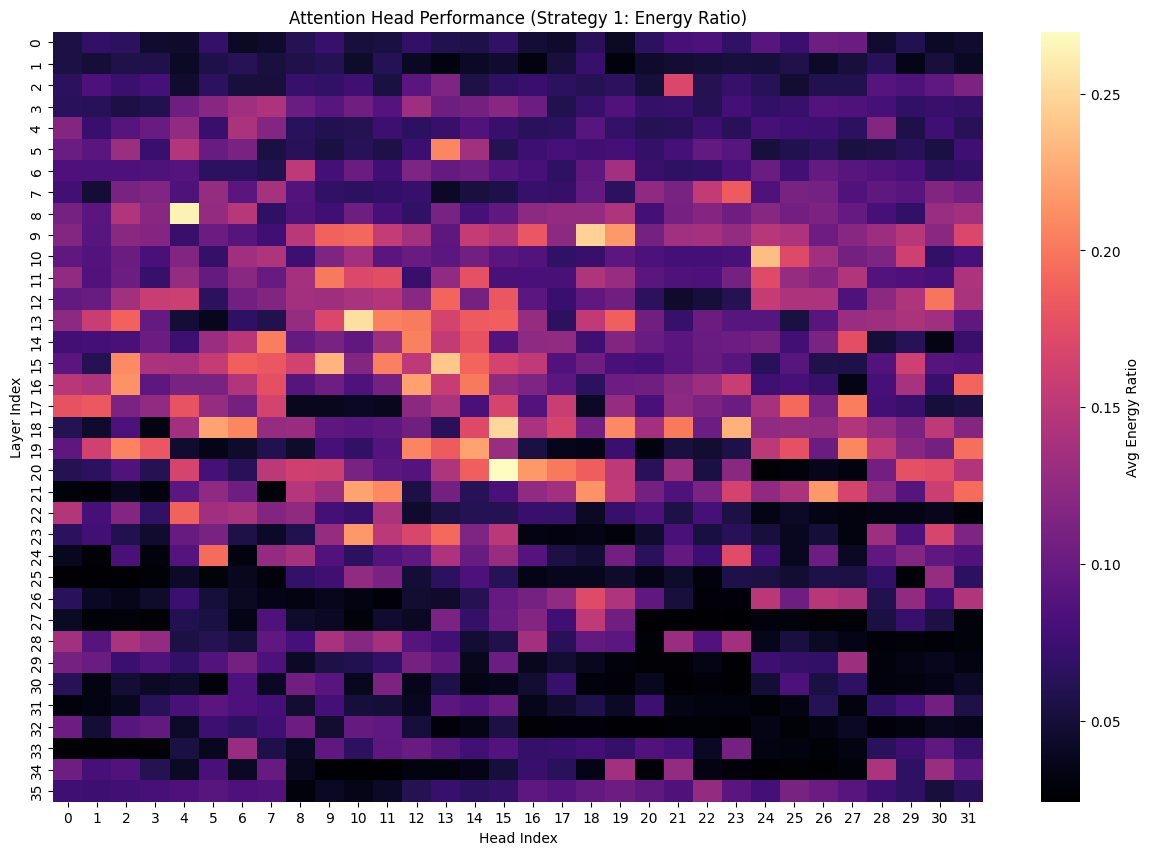

In [6]:
evaluator.visualize_results(scores)

In [7]:
class ImageSelfAttentionVisualizer:
    def __init__(self, model_path="Qwen/Qwen3-VL-4B-Instruct", device="cuda"):
        print(f"--- Loading {model_path} ---")
        self.device = device
        # Load with eager attention
        self.model = AutoModelForVision2Seq.from_pretrained(
            model_path,
            torch_dtype=torch.float16,
            _attn_implementation="eager",
            trust_remote_code=True,
            device_map=device
        )
        self.processor = AutoProcessor.from_pretrained(model_path, trust_remote_code=True)
        print("Model loaded.")

    def get_attention_data(self, image_path, caption):
        # We perform a standard forward pass
        messages = [
            {"role": "user", "content": [{"type": "image", "image": image_path}, {"type": "text", "text": "Describe this."}]},
            {"role": "assistant", "content": [{"type": "text", "text": caption}]}
        ]
        text_prompt = self.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
        
        inputs = self.processor(
            text=[text_prompt],
            images=[Image.open(image_path)],
            padding=True,
            return_tensors="pt"
        ).to(self.device)
        
        with torch.no_grad():
            outputs = self.model(**inputs, output_attentions=True)
            
        return outputs.attentions, inputs

    def extract_image_matrix(self, attentions, inputs, layer_idx):
        input_ids = inputs.input_ids[0].cpu().numpy()
        
        # 1. Locate Vision Tokens Range
        vis_start = self.processor.tokenizer.convert_tokens_to_ids("<|vision_start|>")
        vis_end = self.processor.tokenizer.convert_tokens_to_ids("<|vision_end|>")
        
        start_indices = np.where(input_ids == vis_start)[0]
        end_indices = np.where(input_ids == vis_end)[0]
        
        if len(start_indices) == 0 or len(end_indices) == 0:
            return None
            
        # Range of indices corresponding to the image
        img_start_idx = start_indices[0] + 1
        img_end_idx = end_indices[0]
        
        # 2. Extract Layer Attention
        # Shape: [1, Heads, SeqLen, SeqLen]
        layer_att = attentions[layer_idx]
        
        # 3. Average across Heads
        # Shape: [SeqLen, SeqLen]
        avg_att = layer_att[0].mean(dim=0)
        
        # 4. Slice the Sub-Matrix for Image-to-Image
        # Rows = Image Tokens (Queries)
        # Cols = Image Tokens (Keys)
        # Shape: [N_Image_Tokens, N_Image_Tokens]
        img_matrix = avg_att[img_start_idx:img_end_idx, img_start_idx:img_end_idx]
        
        return img_matrix.float().cpu().numpy()

def process_dataset(visualizer, json_dir, image_dir, output_dir, limit=5):
    os.makedirs(output_dir, exist_ok=True)
    json_files = sorted([f for f in os.listdir(json_dir) if f.endswith('.json')])[:limit]
    
    print(f"--- Generating Self-Attention Matrices for {len(json_files)} images ---")
    
    # We will sample 3 distinct layers to see the evolution
    
    target_layers = list(range(36))
    
    for json_file in tqdm(json_files):
        try:
            with open(os.path.join(json_dir, json_file), 'r') as f: data = json.load(f)
        except: continue
            
        img_filename = data['image']
        caption = data['caption']
        image_path = os.path.join(image_dir, img_filename)
        
        if not os.path.exists(image_path): continue
        
        # Run Model Once
        attentions, inputs = visualizer.get_attention_data(image_path, caption)
        
        for layer in target_layers:
            # Extract Matrix
            matrix = visualizer.extract_image_matrix(attentions, inputs, layer_idx=layer)
            
            if matrix is not None:
                # Plotting the Matrix
                plt.figure(figsize=(10, 8))
                sns.heatmap(np.log(matrix + 1e-6), cmap="viridis", square=True, cbar_kws={'label': 'Log Attention Weight'})
                
                plt.title(f"Image Self-Attention Matrix\nImage: {img_filename} | Layer: {layer}")
                plt.xlabel("Key Image Tokens (Source)")
                plt.ylabel("Query Image Tokens (Target)")
                
                # Invert Y axis so index 0 is at top (matrix style)
                plt.gca().invert_yaxis() 
                
                # Save
                save_name = f"{img_filename.replace('.', '_')}_L{layer}_matrix.png"
                plt.savefig(os.path.join(output_dir, save_name))
                plt.close()
                
        del attentions, inputs
        torch.cuda.empty_cache()
    
    print(f"Results saved in {output_dir}")

    
visualizer = ImageSelfAttentionVisualizer(model_path="Qwen/Qwen3-VL-4B-Instruct")    

--- Loading Qwen/Qwen3-VL-4B-Instruct ---


/root/miniconda3/envs/py3.10/lib/python3.10/site-packages/transformers/models/auto/modeling_auto.py:2253: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

Model loaded.


In [8]:
OUT_DIR = "Self_Attention_Matrices"

In [9]:
process_dataset(visualizer,JSON_DIR,IMG_DIR, OUT_DIR,limit=1)

--- Generating Self-Attention Matrices for 1 images ---


100%|██████████| 1/1 [00:27<00:00, 27.85s/it]

Results saved in Self_Attention_Matrices


In [10]:
import os
import re
import ipywidgets as widgets
from IPython.display import display, Image as IPImage
IMG_DIR = "Self_Attention_Matrices"

In [13]:
matrix_data = {}
files = [f for f in os.listdir(IMG_DIR) if f.endswith("_matrix.png")]

for f in files:
    # Regex to extract Image ID and Layer ID
    # Matches format: "P1234_png_L20_matrix.png"
    match = re.search(r"(.+)_L(\d+)_matrix\.png", f)
    if match:
        img_id = match.group(1)
        layer_idx = int(match.group(2))
        
        if img_id not in matrix_data:
            matrix_data[img_id] = {}
        matrix_data[img_id][layer_idx] = os.path.join(IMG_DIR, f)

sorted_images = sorted(matrix_data.keys())

if not sorted_images:
    print(f"❌ No matrix images found in '{IMG_DIR}'. Check your path.")
else:
    # 2. Create Widgets
    dropdown = widgets.Dropdown(
        options=sorted_images,
        description='Image:',
        disabled=False,
    )

    slider = widgets.IntSlider(
        value=0,
        min=0,
        max=35, # Adjust max if you have fewer layers
        step=1,
        description='Layer:',
        continuous_update=True # Updates immediately while dragging
    )
    
    # Output area to display the image
    output_view = widgets.Output()

    # 3. Define Update Logic
    def update_display(*args):
        img_id = dropdown.value
        layer = slider.value
        
        with output_view:
            output_view.clear_output(wait=True) # wait=True reduces flickering
            
            if img_id in matrix_data and layer in matrix_data[img_id]:
                filepath = matrix_data[img_id][layer]
                display(IPImage(filename=filepath, width=1000))
            else:
                print(f"⚠️ No matrix generated for Layer {layer} (Image: {img_id})")

    # 4. Link Widgets to Logic
    dropdown.observe(update_display, names='value')
    slider.observe(update_display, names='value')

    # 5. Show Interface
    ui = widgets.VBox([dropdown, slider, output_view])
    
    # Initialize view
    update_display()
    display(ui)`